In [1]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

def load_fingerprints_from_csv(filepath: str) -> pd.DataFrame:
    """Loads spatial fingerprints from a CSV file."""
    try:
        df = pd.read_csv(filepath, index_col=0)
        return df[['moran', 'entropy', 'eds']]
    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found.")
        return None
    except Exception as e:
        print(f"An error occurred while reading the CSV: {e}")
        return None

def find_best_gmm(id_fingerprints: pd.DataFrame, max_components: int = 8):
    """Tests different numbers of GMM components and finds the best one using BIC.
    Returns the optimal number of components.
    """
    id_data = id_fingerprints.to_numpy()
    bic_scores = []
    component_range = range(1, max_components + 1)

    print(f"\n--- Model Selection: Finding the best number of components (1 to {max_components}) ---")
    for n in component_range:
        gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
        gmm.fit(id_data)
        bic_scores.append(gmm.bic(id_data))
        print(f"  Tested {n} components, BIC = {bic_scores[-1]:.2f}")

    best_n_components = np.argmin(bic_scores) + 1
    
    print("-" * 20)
    print(f"CONCLUSION: The optimal number of components is {best_n_components}, as it has the lowest BIC score.")
    print("-" * 20)

    plt.figure(figsize=(5, 4))
    plt.plot(component_range, bic_scores, marker='o', linestyle='--')
    plt.title('GMM Model Selection using BIC')
    plt.xlabel('Number of Components')
    plt.ylabel('Bayesian Information Criterion (BIC)')
    plt.xticks(component_range)
    plt.axvline(best_n_components, color='red', linestyle=':', label=f'Best k = {best_n_components}')
    plt.legend()
    plt.show()

    return best_n_components

def build_id_gmm_model(id_fingerprints: pd.DataFrame, n_components: int):
    """Builds a Gaussian Mixture Model from the in-distribution fingerprints."""
    id_data = id_fingerprints.to_numpy()
    
    print("\n--- Building final In-Distribution GMM Model ---")
    print(f"Using {n_components} component(s).")
    
    gmm_model = GaussianMixture(n_components=n_components, random_state=42, n_init=10)
    gmm_model.fit(id_data)
    
    id_log_likelihoods = gmm_model.score_samples(id_data)
    id_likelihoods = np.exp(id_log_likelihoods)
    max_density = np.max(id_likelihoods)
    
    print(f"Maximum Likelihood Density on ID data: {max_density}\n")
    
    return gmm_model, max_density

def calculate_ood_scores_gmm(ood_fingerprints: pd.DataFrame, id_model):
    """Calculates OoD scores using both methods for comparison."""
    gmm_model, max_density = id_model
    ood_data = ood_fingerprints.to_numpy()

    # Get the likelihood values for the OoD samples
    log_p_values = gmm_model.score_samples(ood_data)
    p_values = np.exp(log_p_values)
    
    # --- Score 1: Normalized Likelihood (bounded) ---
    ood_scores_normalized = (max_density - p_values) / (max_density + 1e-9)
    ood_scores_normalized = np.clip(ood_scores_normalized, 0, 1)

    # --- Score 2: Raw Negative Log-Likelihood (unbounded) ---
    ood_scores_nll = -log_p_values # This is more direct than -log(exp(log_p))

    # --- Score 3: Zero-Floored NLL (unbounded, interpretable baseline) ---
    # First, find the minimum NLL for the ID model
    nll_min = -np.log(max_density + 1e-20)
    # Then subtract this minimum from the raw NLL scores
    ood_scores_nll_zero_floored = ood_scores_nll - nll_min
    
    # Create the final DataFrame
    results_df = ood_fingerprints.copy()
    results_df['ood_score_normalized'] = ood_scores_normalized
    results_df['ood_score_nll'] = ood_scores_nll
    results_df['ood_score_nll_zero_floored'] = ood_scores_nll_zero_floored
    
    return results_df
    


--- Model Selection: Finding the best number of components (1 to 8) ---
  Tested 1 components, BIC = -31888.15
  Tested 2 components, BIC = -33410.92
  Tested 3 components, BIC = -33582.61
  Tested 4 components, BIC = -33562.33
  Tested 5 components, BIC = -33651.04
  Tested 6 components, BIC = -33604.96
  Tested 7 components, BIC = -33522.97
  Tested 8 components, BIC = -33512.94
--------------------
CONCLUSION: The optimal number of components is 5, as it has the lowest BIC score.
--------------------


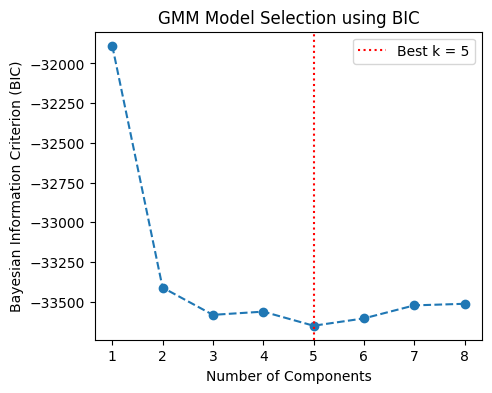


--- Building final In-Distribution GMM Model ---
Using 5 component(s).
Maximum Likelihood Density on ID data: 57133.22005018353

--- OoD Score Calculation Results (Comparing All Three Methods) ---
                            moran   entropy       eds  ood_score_normalized  \
aachen_000123_000019     0.427150  0.002195  0.179020              0.999987   
bremen_000024_000019     0.430781  0.003008  0.172878              0.999970   
weimar_000008_000019     0.431210  0.003153  0.154740              0.999916   
jena_000012_000019       0.436019  0.009730  0.166572              0.999734   
erfurt_000041_000019     0.433805  0.013325  0.175013              0.999681   
...                           ...       ...       ...                   ...   
hanover_000000_027998    0.455968  0.061897  0.109170              0.884085   
cologne_000109_000019    0.459787  0.058240  0.084515              0.883022   
darmstadt_000018_000019  0.457905  0.057219  0.096442              0.883004   
tubingen_000

In [2]:
# PLEASE REPLACE THESE WITH YOUR ACTUAL FILE PATHS
id_csv_path = '/fast/AG_Kainmueller/vguarin/aggrigator_experiments/output/tables/spatial_fingerprint_ade20k_deeplabv3_semantic_cityscapes_0_00_dropout_pu.csv' # Your ID data
ood_csv_path = '/fast/AG_Kainmueller/vguarin/aggrigator_experiments/output/tables/spatial_fingerprint_ade20k_deeplabv3_semantic_cityscapes_1_00_dropout_pu.csv' # Your OoD data

# 1. Load the ID data and build the model
id_fingerprints = load_fingerprints_from_csv(id_csv_path)
    
if id_fingerprints is not None:
    best_k = find_best_gmm(id_fingerprints, max_components=8)
    id_model = build_id_gmm_model(id_fingerprints, n_components=best_k)
    ood_fingerprints = load_fingerprints_from_csv(ood_csv_path)

    if ood_fingerprints is not None:
        results = calculate_ood_scores_gmm(ood_fingerprints, id_model)

        print("--- OoD Score Calculation Results (Comparing All Three Methods) ---")
        # Sort by the zero-floored NLL score to see the results
        print(results.sort_values(by='ood_score_nll_zero_floored', ascending=False))

        # Check the misclassification rate using the normalized score
        misclassified_count = (results['ood_score_normalized'] <= 0.7).sum()
        total_count = len(results)
        print(f"\nSummary: {misclassified_count} out of {total_count} OoD samples have a normalized score <= 0.7.")

Generating pairplot for visual inspection of ID data...


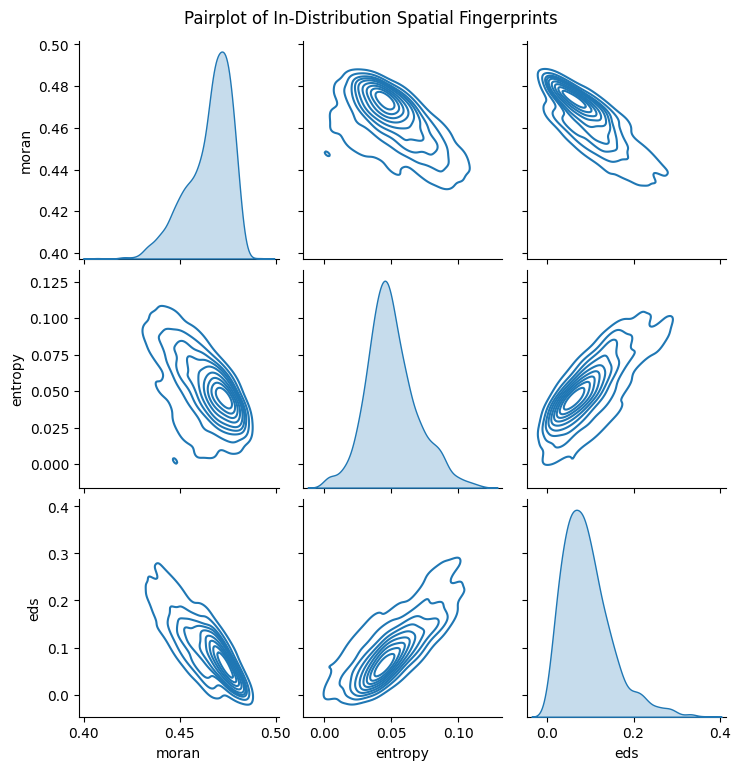

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating pairplot for visual inspection of ID data...")
sns.pairplot(id_fingerprints, kind='kde')
plt.suptitle("Pairplot of In-Distribution Spatial Fingerprints", y=1.02)
plt.show()

In [125]:
from scipy.stats import shapiro

print("\n--- Shapiro-Wilk Test for Marginal Normality ---")
for column in id_fingerprints.columns:
    stat, p_value = shapiro(id_fingerprints[column])
    print(f"Variable: {column}")
    print(f"  Statistic={stat:.4f}, p-value={p_value:.4f}")
    if p_value > 0.05:
        print("  Conclusion: The data looks Gaussian (fail to reject H₀).")
    else:
        print("  Conclusion: The data does NOT look Gaussian (reject H₀).")


--- Shapiro-Wilk Test for Marginal Normality ---
Variable: moran
  Statistic=0.9320, p-value=0.0000
  Conclusion: The data does NOT look Gaussian (reject H₀).
Variable: entropy
  Statistic=0.9815, p-value=0.0000
  Conclusion: The data does NOT look Gaussian (reject H₀).
Variable: eds
  Statistic=0.9259, p-value=0.0000
  Conclusion: The data does NOT look Gaussian (reject H₀).


In [ ]:
import pingouin as pg

print("\n--- Henze-Zirkler Test for Multivariate Normality ---")
# The test expects a NumPy array
results = pg.multivariate_normality(id_fingerprints.to_numpy(), alpha=0.05)
print(results)


--- Henze-Zirkler Test for Multivariate Normality ---
HZResults(hz=np.float64(38.72122993360582), pval=np.float64(1.3667914127995167e-193), normal=False)
